In [101]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns   
from scipy.stats import chi2_contingency
import warnings
warnings.filterwarnings("ignore", category=ImportWarning)


In [157]:
from pathlib import Path
import sys

root_dir = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
if str(root_dir) not in sys.path:
    sys.path.append(str(root_dir))

from funciones.variables_modelo import (
    VARIABLES_CATEGORICAS_CRAMER,
    VARIABLES_CATEGORICAS_EDA,
    VARIABLES_NUMERICAS,
 )

categoricas = VARIABLES_CATEGORICAS_EDA.copy()
categoricas1 = VARIABLES_CATEGORICAS_CRAMER.copy()
numericas = VARIABLES_NUMERICAS.copy()

# *Analisis Exploratorio de datos*

In [102]:
df = pd.read_csv('../datos/brutos/base_fraude_interactuar_microempresarios_60000.csv')
df.head()

,ID_TRANSACCION,ID_CLIENTE,EDAD,SEXO,TIPO_CLIENTE,SEGMENTO,ANTIGUEDAD_MESES,INGRESOS_MENSUALES,EGRESOS_MENSUALES,MONTO_TRANSACCION,...,CAMBIO_CLAVE_RECIENTE,NUM_TRANSACCIONES_DIA,MONTO_PROMEDIO_30D,NUM_INTENTOS_FALLIDOS,CLIENTE_NUEVO,BENEFICIARIO_NUEVO,PAIS_DESTINO,FIN_DE_SEMANA,MES,FRAUDE
0,TX0012629,CLI02084,60,M,Microempresario,Comercio,15,3913655.0,3148612.0,186052,...,0,3,183936,0,0,0,CO,0,3,0
1,TX0037731,CLI03274,54,F,Pequeño empresario,Microempresa,24,10757188.0,1613578.0,1200273,...,0,5,1481367,2,0,0,CO,0,12,0
2,TX0039992,CLI12186,44,M,Microempresario,Emprendimiento,23,2436868.0,1732651.0,242589,...,0,1,404793,0,0,0,CO,0,11,0
3,TX0008526,CLI04248,22,F,Microempresario,Servicios,15,11709479.0,7468662.0,2490968,...,0,2,1252162,0,0,0,CO,0,12,0
4,TX0008280,CLI11936,52,M,Pequeño empresario,Microempresa,10,10128545.0,6640160.0,334308,...,0,3,439782,0,0,0,CO,0,11,0


In [103]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Data columns (total 26 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ID_TRANSACCION          60000 non-null  str    
 1   ID_CLIENTE              60000 non-null  str    
 2   EDAD                    60000 non-null  int64  
 3   SEXO                    59520 non-null  str    
 4   TIPO_CLIENTE            60000 non-null  str    
 5   SEGMENTO                59640 non-null  str    
 6   ANTIGUEDAD_MESES        60000 non-null  int64  
 7   INGRESOS_MENSUALES      59760 non-null  float64
 8   EGRESOS_MENSUALES       59760 non-null  float64
 9   MONTO_TRANSACCION       60000 non-null  int64  
 10  TIPO_TRANSACCION        60000 non-null  str    
 11  CANAL                   59820 non-null  str    
 12  CIUDAD                  60000 non-null  str    
 13  HORA_TRANSACCION        60000 non-null  str    
 14  DISTANCIA_UBICACION_KM  59280 non-null  float64
 

In [104]:
df.isnull().sum()

ID_TRANSACCION              0
ID_CLIENTE                  0
EDAD                        0
SEXO                      480
TIPO_CLIENTE                0
SEGMENTO                  360
ANTIGUEDAD_MESES            0
INGRESOS_MENSUALES        240
EGRESOS_MENSUALES         240
MONTO_TRANSACCION           0
TIPO_TRANSACCION            0
CANAL                     180
CIUDAD                      0
HORA_TRANSACCION            0
DISTANCIA_UBICACION_KM    720
DISPOSITIVO_NUEVO           0
CAMBIO_CLAVE_RECIENTE       0
NUM_TRANSACCIONES_DIA       0
MONTO_PROMEDIO_30D          0
NUM_INTENTOS_FALLIDOS       0
CLIENTE_NUEVO               0
BENEFICIARIO_NUEVO          0
PAIS_DESTINO                0
FIN_DE_SEMANA               0
MES                         0
FRAUDE                      0
dtype: int64

Copia de df y verificacion de duplicados

In [105]:
df1 = df.copy()
duplicados = df1.duplicated().sum()
duplicados

np.int64(0)

Asegurar target binaria

In [106]:
df1['FRAUDE'] = pd.to_numeric(df['FRAUDE'], errors='coerce')
df1 = df1.dropna(subset=['FRAUDE']).copy()
df1['FRAUDE'] = df1['FRAUDE'].astype(int)
print(df1['FRAUDE'].unique())


[0 1]


Conversión tipo de dato

In [107]:
df1['HORA'] = pd.to_datetime(df1['HORA_TRANSACCION'], format='%H:%M').dt.hour

In [108]:
df1['SEXO'] = df1['SEXO'].astype('category')
df1['SEGMENTO'] = df1['SEGMENTO'].astype('category')
df1['CANAL'] = df1['CANAL'].astype('category')
df1['PAIS_DESTINO'] = df1['PAIS_DESTINO'].astype('category')    
df1['CIUDAD'] = df1['CIUDAD'].astype('category')
df1['TIPO_CLIENTE'] = df1['TIPO_CLIENTE'].astype('category')    

Analisis univariado

**Categoricas**

In [109]:
def analisis_categorico(df1, columnas):
    for col in columnas:
        print(f"\n{'='*50}")
        print(f"Variable: {col}")
        print(f"{'='*50}")
        print(df1[col].value_counts(dropna=False))
        print("\nPorcentaje:")
        print((df1[col].value_counts(normalize=True, dropna=False) * 100).round(2))

In [110]:
categoricas = ['SEXO', 'SEGMENTO', 'CANAL', 'PAIS_DESTINO', 'CIUDAD', 'TIPO_CLIENTE', 'TIPO_TRANSACCION', 'DISPOSITIVO_NUEVO', 'CAMBIO_CLAVE_RECIENTE', 'BENEFICIARIO_NUEVO']   
analisis_categorico(df1, categoricas)


Variable: SEXO
SEXO
M      30909
F      28611
NaN      480
Name: count, dtype: int64

Porcentaje:
SEXO
M      51.52
F      47.68
NaN     0.80
Name: proportion, dtype: float64

Variable: SEGMENTO
SEGMENTO
Microempresa      22410
Emprendimiento    13219
Servicios          9678
Comercio           9576
Preferencial       4757
NaN                 360
Name: count, dtype: int64

Porcentaje:
SEGMENTO
Microempresa      37.35
Emprendimiento    22.03
Servicios         16.13
Comercio          15.96
Preferencial       7.93
NaN                0.60
Name: proportion, dtype: float64

Variable: CANAL
CANAL
App             24811
Web             13258
Corresponsal     8930
Oficina          8002
Cajero           4819
NaN               180
Name: count, dtype: int64

Porcentaje:
CANAL
App             41.35
Web             22.10
Corresponsal    14.88
Oficina         13.34
Cajero           8.03
NaN              0.30
Name: proportion, dtype: float64

Variable: PAIS_DESTINO
PAIS_DESTINO
CO    54606
US     2092


In [155]:
categoricas

['SEXO',
 'SEGMENTO',
 'CANAL',
 'PAIS_DESTINO',
 'CIUDAD',
 'TIPO_CLIENTE',
 'TIPO_TRANSACCION',
 'DISPOSITIVO_NUEVO',
 'CAMBIO_CLAVE_RECIENTE',
 'BENEFICIARIO_NUEVO']

In [156]:
numericas

['EDAD',
 'ANTIGUEDAD_MESES',
 'INGRESOS_MENSUALES',
 'EGRESOS_MENSUALES',
 'MONTO_TRANSACCION',
 'DISTANCIA_UBICACION_KM',
 'NUM_TRANSACCIONES_DIA',
 'MONTO_PROMEDIO_30D',
 'NUM_INTENTOS_FALLIDOS']

**Númericas**

In [111]:
def analisis_numerico(df, columnas):
    resumen = df[columnas].describe().T
    
    resumen['nulos'] = df[columnas].isnull().sum()
    resumen['%_nulos'] = (df[columnas].isnull().mean() * 100).round(2)
    
    return resumen

In [112]:
numericas = ['EDAD', 'ANTIGUEDAD_MESES', 'INGRESOS_MENSUALES', 'EGRESOS_MENSUALES', 'MONTO_TRANSACCION', 'DISTANCIA_UBICACION_KM', 'NUM_TRANSACCIONES_DIA', 'MONTO_PROMEDIO_30D', 'NUM_INTENTOS_FALLIDOS']
analisis_numerico(df1, numericas)

,count,mean,std,min,25%,50%,75%,max,nulos,%_nulos
EDAD,60000.0,4.004307e+01,1.123432e+01,18.00,32.00,40.0,4.800000e+01,75.0,0,0.0
ANTIGUEDAD_MESES,60000.0,3.198952e+01,1.782473e+01,1.00,19.00,29.0,4.200000e+01,149.0,0,0.0
INGRESOS_MENSUALES,59760.0,7.839762e+06,7.844825e+06,700000.00,3086820.00,5472452.5,9.759074e+06,80000000.0,240,0.4
EGRESOS_MENSUALES,59760.0,4.324062e+06,4.760840e+06,105000.00,1529645.25,2865611.0,5.352871e+06,75089553.0,240,0.4
MONTO_TRANSACCION,60000.0,1.165799e+06,1.828334e+06,20000.00,272045.75,610016.0,1.328472e+06,50000000.0,0,0.0
DISTANCIA_UBICACION_KM,59280.0,2.697025e+01,2.204231e+01,0.01,10.93,21.2,3.694250e+01,250.0,720,1.2
NUM_TRANSACCIONES_DIA,60000.0,3.079850e+00,1.679193e+00,1.00,2.00,3.0,4.000000e+00,14.0,0,0.0
MONTO_PROMEDIO_30D,60000.0,9.454224e+05,1.082864e+06,50000.00,313616.00,610960.5,1.164939e+06,12000000.0,0,0.0
NUM_INTENTOS_FALLIDOS,60000.0,7.992333e-01,8.949336e-01,0.00,0.00,1.0,1.000000e+00,6.0,0,0.0


**Graficos variables categoricas**

In [113]:
def graficos_categoricos(df, columnas):
    n_columnas = 3
    filas = (len(columnas) + n_columnas - 1) // n_columnas
    
    fig, axes = plt.subplots(filas, n_columnas, figsize=(15, 5 * filas))
    axes = np.atleast_1d(axes).flatten()

    for i, col in enumerate(columnas):
        df[col].value_counts(dropna=False).plot(
            kind='bar',
            ax=axes[i],
            title=col
        )
        axes[i].set_xlabel('')
        axes[i].set_ylabel('Frecuencia')
        axes[i].tick_params(axis='x', rotation=45)

    for j in range(len(columnas), len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()

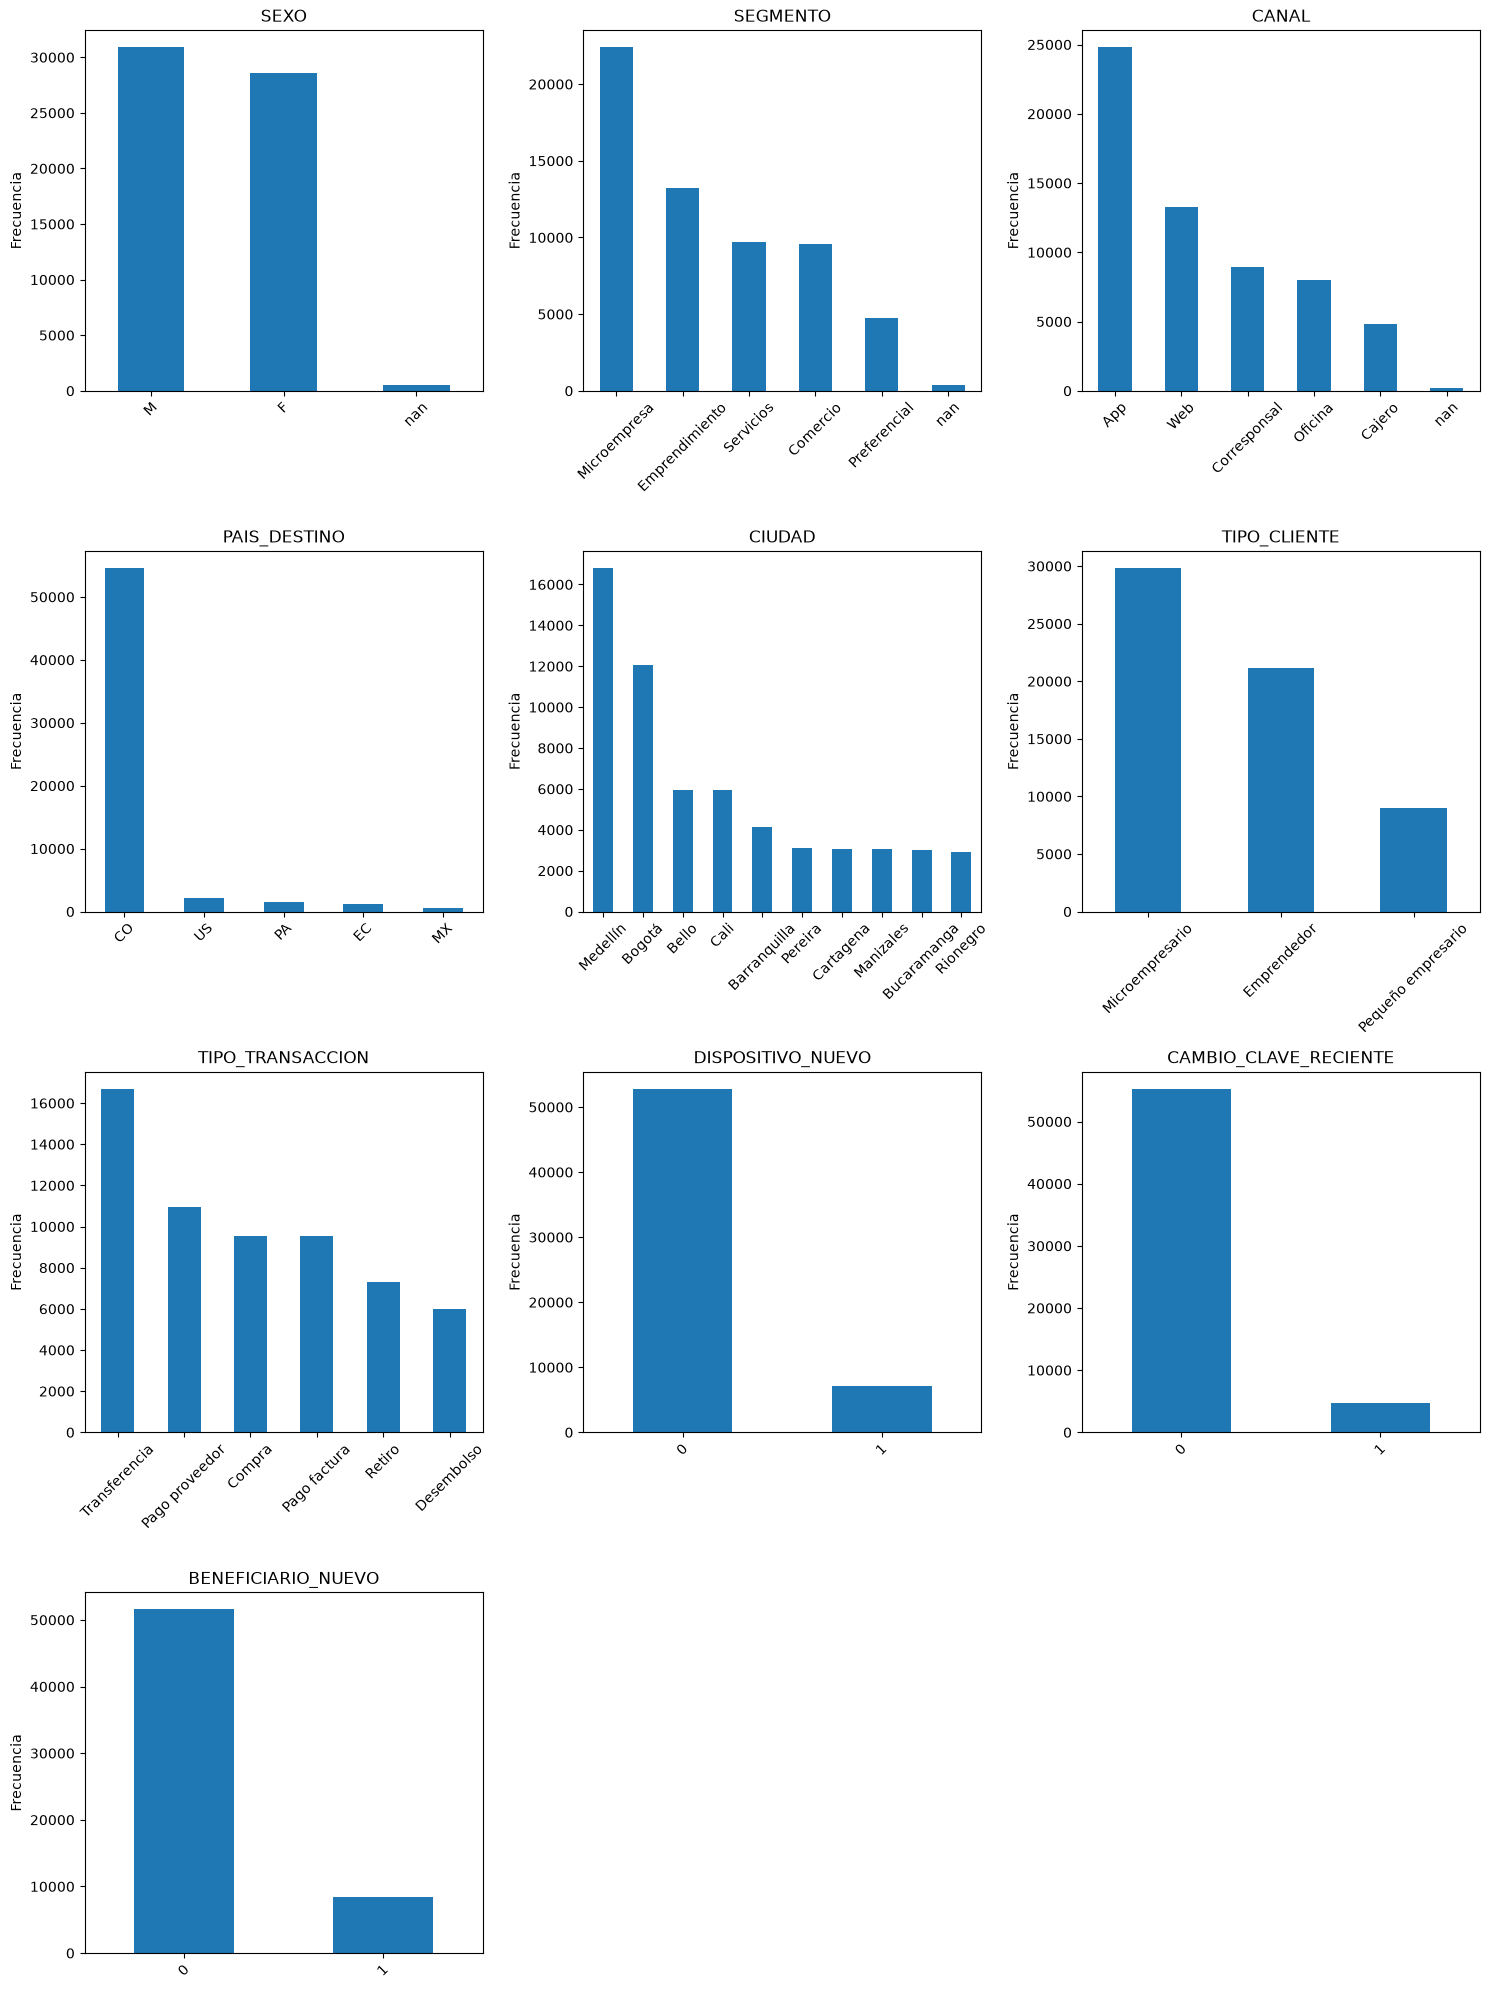

In [114]:
graficos_categoricos(df, categoricas)

**Graficos variables numericas**

In [115]:
def boxplots_numericos(df, columnas):
    filas = (len(columnas) + 3) // 3

    fig, axes = plt.subplots(filas, 3, figsize=(15, 6 * filas))
    axes = axes.flatten()

    for i, col in enumerate(columnas):
        df[col].plot(
            kind='box',
            ax=axes[i],
            title=col
        )

        axes[i].set_ylabel(col)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()

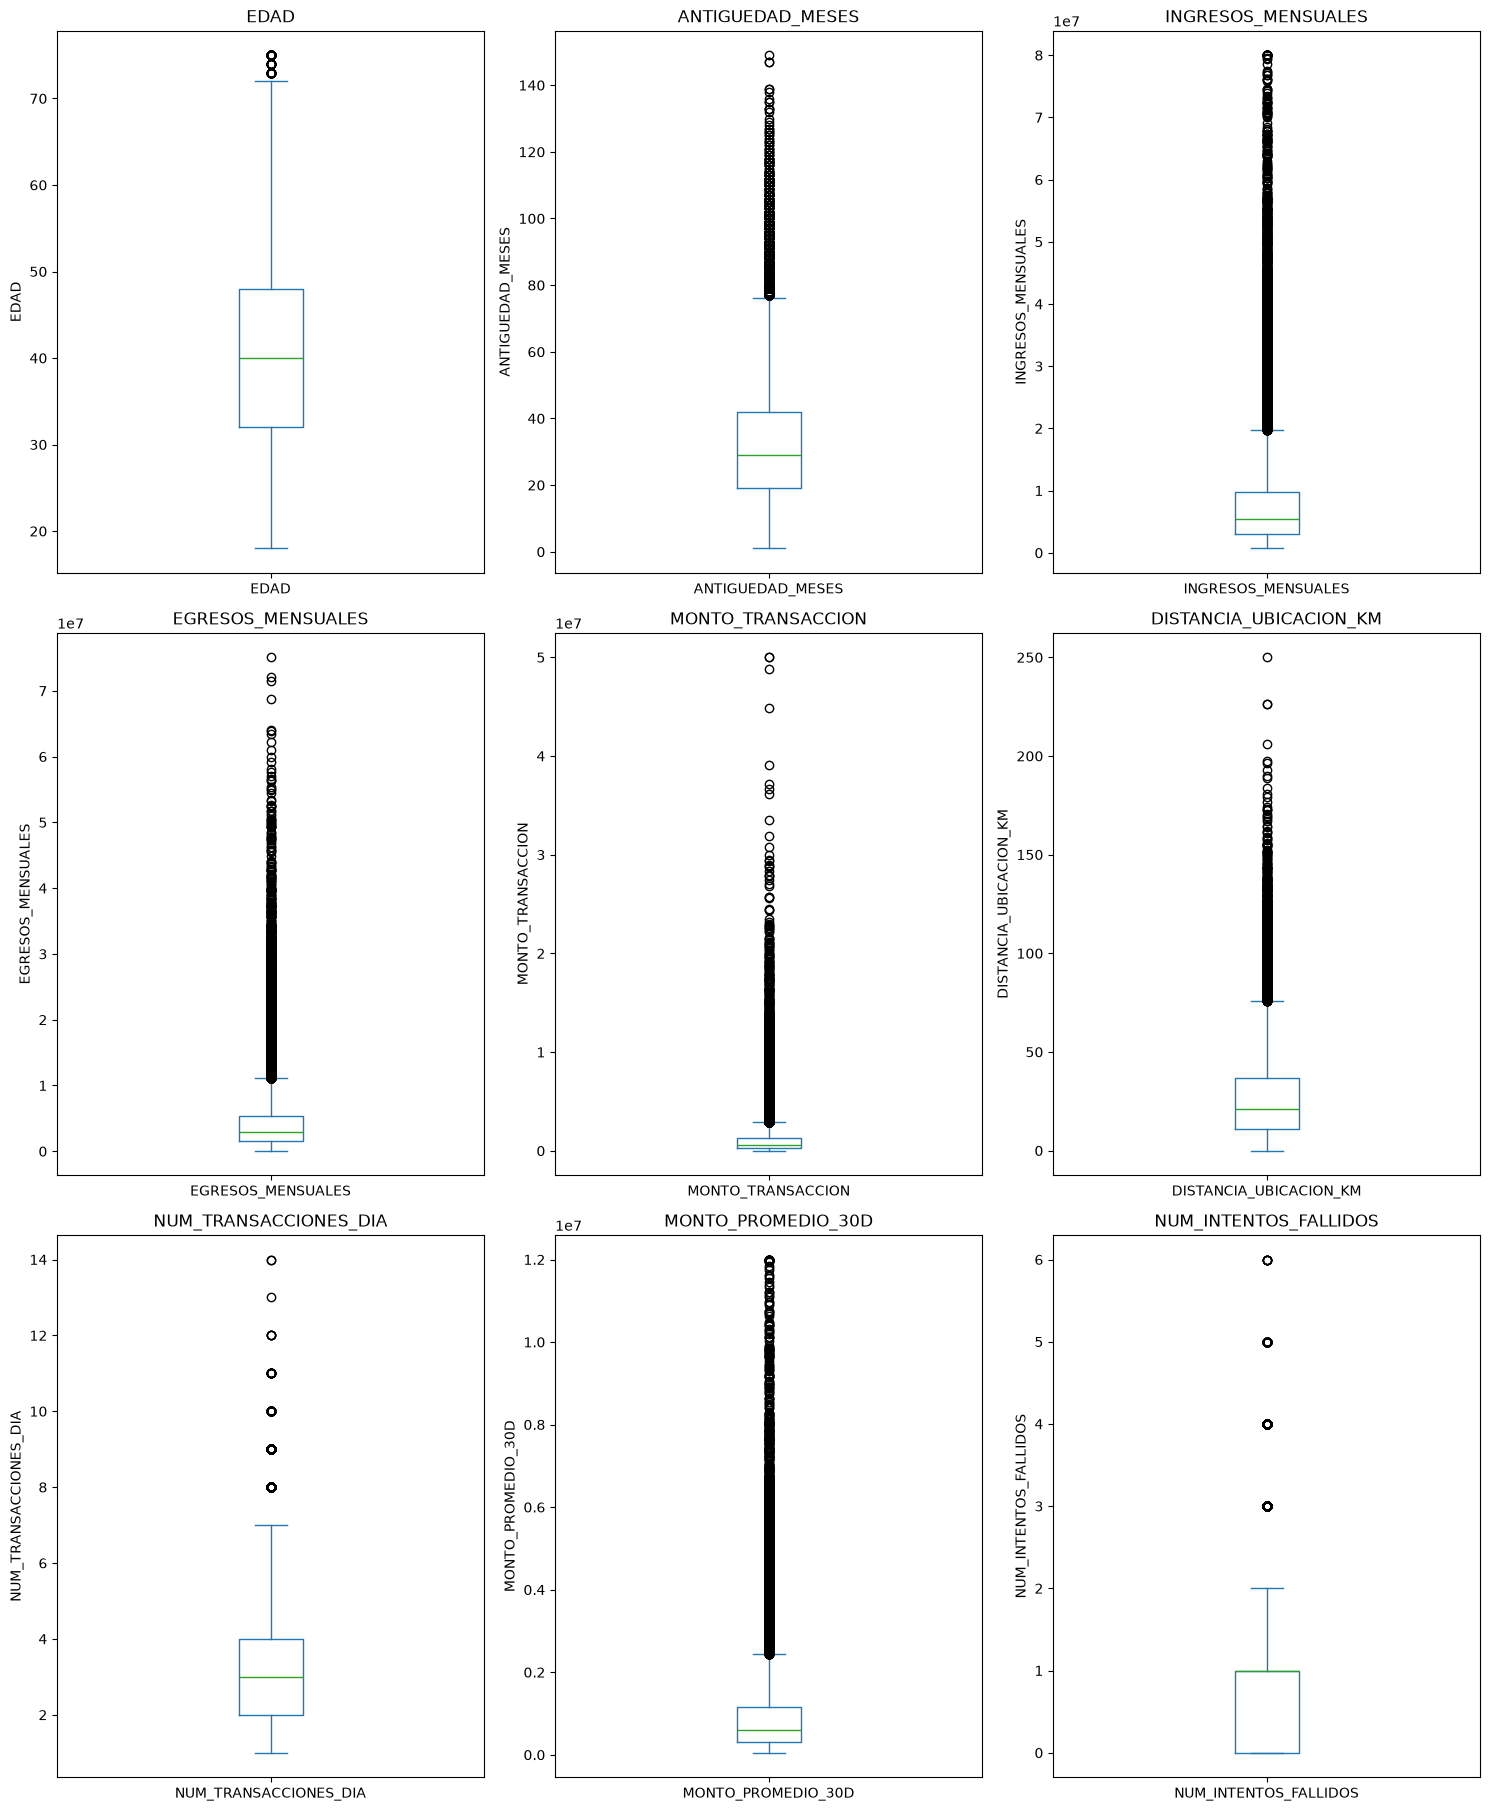

In [116]:
boxplots_numericos(df, numericas)

In [117]:
def imputar_datos(df1, numericas, categoricas):

    # Numéricas → mediana
    for col in numericas:
        df1[col] = df1[col].fillna(df1[col].median())

    # Categóricas → moda
    for col in categoricas:
        df1[col] = df1[col].fillna(df1[col].mode()[0])

    return df1

In [118]:
df1 = imputar_datos(df1, numericas, categoricas)

Analisis Bivariado

**Traget vs Categoricas**


In [119]:
Por_Sexo = pd.crosstab(df['SEXO'], df['FRAUDE'], margins=True)
Por_Sexo = pd.concat([Por_Sexo.drop('All').sort_values(1, ascending=False), Por_Sexo.loc[['All']]])
Por_Sexo

FRAUDE,0,1,All
SEXO,,,
M,29576,1333,30909
F,27402,1209,28611
All,56978,2542,59520


In [120]:
Por_Segmento = pd.crosstab(df['SEGMENTO'], df['FRAUDE'], margins=True)
Por_Segmento = pd.concat([Por_Segmento.drop('All').sort_values(1, ascending=False), Por_Segmento.loc[['All']]])
Por_Segmento

FRAUDE,0,1,All
SEGMENTO,,,
Microempresa,21463,947,22410
Emprendimiento,12675,544,13219
Comercio,9145,431,9576
Servicios,9289,389,9678
Preferencial,4518,239,4757
All,57090,2550,59640


In [121]:
Por_Canal = pd.crosstab(df['CANAL'], df['FRAUDE'], margins=True)
Por_Canal = pd.concat([Por_Canal.drop('All').sort_values(1, ascending=False), Por_Canal.loc[['All']]])
Por_Canal

FRAUDE,0,1,All
CANAL,,,
App,23565,1246,24811
Web,12739,519,13258
Corresponsal,8621,309,8930
Oficina,7694,308,8002
Cajero,4642,177,4819
All,57261,2559,59820


In [122]:
Por_Pais_destino = pd.crosstab(df['PAIS_DESTINO'], df['FRAUDE'], margins=True)
Por_Pais_destino = pd.concat([Por_Pais_destino.drop('All').sort_values(1, ascending=False), Por_Pais_destino.loc[['All']]])
Por_Pais_destino

FRAUDE,0,1,All
PAIS_DESTINO,,,
CO,52343,2263,54606
US,1949,143,2092
EC,1174,60,1234
PA,1398,55,1453
MX,569,46,615
All,57433,2567,60000


In [123]:
Por_ciudad= pd.crosstab(df['CIUDAD'], df['FRAUDE'], margins=True)
Por_ciudad = pd.concat([Por_ciudad.drop('All').sort_values(1, ascending=False), Por_ciudad.loc[['All']]])
Por_ciudad

FRAUDE,0,1,All
CIUDAD,,,
Medellín,16094,714,16808
Bogotá,11525,512,12037
Bello,5662,302,5964
Cali,5689,252,5941
Barranquilla,3928,195,4123
Manizales,2911,127,3038
Rionegro,2784,119,2903
Bucaramanga,2887,118,3005
Pereira,3010,116,3126


In [124]:
Por_Tipo_cliente = pd.crosstab(df['TIPO_CLIENTE'], df['FRAUDE'], margins=True)
Por_Tipo_cliente = pd.concat([Por_Tipo_cliente.drop('All').sort_values(1, ascending=False), Por_Tipo_cliente.loc[['All']]])
Por_Tipo_cliente

FRAUDE,0,1,All
TIPO_CLIENTE,,,
Microempresario,28550,1289,29839
Emprendedor,20233,910,21143
Pequeño empresario,8650,368,9018
All,57433,2567,60000


In [125]:
Por_Cambio_clave = pd.crosstab(df1['CAMBIO_CLAVE_RECIENTE'], df1['FRAUDE'], margins=True)
Por_Cambio_clave = pd.concat([Por_Cambio_clave.drop('All').sort_values(1, ascending=True), Por_Cambio_clave.loc[['All']]])
Por_Cambio_clave

FRAUDE,0,1,All
CAMBIO_CLAVE_RECIENTE,,,
1,4360,351,4711
0,53073,2216,55289
All,57433,2567,60000


In [126]:
Por_Beneficiario_nuevo = pd.crosstab(df1['BENEFICIARIO_NUEVO'], df1['FRAUDE'], margins=True)
Por_Beneficiario_nuevo = pd.concat([Por_Beneficiario_nuevo.drop('All').sort_values(1, ascending=True), Por_Beneficiario_nuevo.loc[['All']]])
Por_Beneficiario_nuevo

FRAUDE,0,1,All
BENEFICIARIO_NUEVO,,,
1,7817,614,8431
0,49616,1953,51569
All,57433,2567,60000


In [127]:
Por_tipo_transaccion = pd.crosstab(df1['TIPO_TRANSACCION'], df1['FRAUDE'], margins=True)
Por_tipo_transaccion = pd.concat([Por_tipo_transaccion.drop('All').sort_values(1, ascending=False), Por_tipo_transaccion.loc[['All']]])
Por_tipo_transaccion

FRAUDE,0,1,All
TIPO_TRANSACCION,,,
Transferencia,15853,848,16701
Pago proveedor,10513,416,10929
Compra,9150,382,9532
Pago factura,9165,363,9528
Retiro,7000,302,7302
Desembolso,5752,256,6008
All,57433,2567,60000


**Traget vs númericas**

In [128]:
df1['RANGO_DISTANCIA_UBICACION_KM'] = pd.cut(df1['DISTANCIA_UBICACION_KM'], bins=[0, 2, 5, 10, 20, 50, 100, float('inf')],
    labels=[
        'Hasta 0km',
        '0km - 2km',
        '2km - 5km',
        '5km - 10km',
        '10km - 20km',
        '20km - 50km',
        'Más de 50km'
    ]
)

In [129]:
tabla_dist_ubica = pd.crosstab(df1['RANGO_DISTANCIA_UBICACION_KM'], df1['FRAUDE'], margins=True)
tabla_dist_ubica = pd.concat([tabla_dist_ubica.drop('All').sort_values(1, ascending=False), tabla_dist_ubica.loc[['All']]])
tabla_dist_ubica

FRAUDE,0,1,All
RANGO_DISTANCIA_UBICACION_KM,,,
10km - 20km,22907,1055,23962
5km - 10km,14045,599,14644
20km - 50km,7032,325,7357
2km - 5km,7551,302,7853
0km - 2km,3756,160,3916
Hasta 0km,1536,75,1611
Más de 50km,606,51,657
All,57433,2567,60000


In [130]:
df1['RANGO_INGRESOS'] = pd.cut(df1['INGRESOS_MENSUALES'], bins=[0, 2_000_000, 5_000_000, 10_000_000, 20_000_000, 50_000_000, float('inf')],
    labels=[
        'Hasta 2M',
        '2M - 5M',
        '5M - 10M',
        '10M - 20M',
        '20M - 50M',
        'Más de 50M'
    ]
)

In [131]:
tabla_ingresos = pd.crosstab(df1['RANGO_INGRESOS'], df1['FRAUDE'], margins=True)
tabla_ingresos = pd.concat([tabla_ingresos.drop('All').sort_values(1, ascending=False), tabla_ingresos.loc[['All']]])
tabla_ingresos

FRAUDE,0,1,All
RANGO_INGRESOS,,,
2M - 5M,19422,856,20278
5M - 10M,17459,778,18237
10M - 20M,10107,468,10575
Hasta 2M,6802,289,7091
20M - 50M,3376,157,3533
Más de 50M,267,19,286
All,57433,2567,60000


In [132]:
df1['RANGO_EGRESOS'] = pd.cut(df1['EGRESOS_MENSUALES'], bins=[0, 2_000_000, 5_000_000, 10_000_000, 20_000_000, 50_000_000, float('inf')],
    labels=[
        'Hasta 2M',
        '2M - 5M',
        '5M - 10M',
        '10M - 20M',
        '20M - 50M',
        'Más de 50M'
    ]
)

In [133]:
tabla_egresos = pd.crosstab(df1['RANGO_EGRESOS'], df1['FRAUDE'], margins=True)
tabla_egresos = pd.concat([tabla_egresos.drop('All').sort_values(1, ascending=False), tabla_egresos.loc[['All']]])
tabla_egresos


FRAUDE,0,1,All
RANGO_EGRESOS,,,
2M - 5M,21862,968,22830
Hasta 2M,19974,862,20836
5M - 10M,10723,512,11235
10M - 20M,3939,171,4110
20M - 50M,900,54,954
Más de 50M,35,0,35
All,57433,2567,60000


In [134]:
df1['RANGO_EDAD'] = pd.cut(df1['EDAD'], bins=[0, 20, 30, 40, 50, 70, float('inf')],
    labels=[
        'Hasta 20',
        '21 - 30',
        '31 - 40',
        '41 - 50',
        '61 - 70',
        'Más de 70'
    ]
)

In [135]:
tabla_edad = pd.crosstab(df1['RANGO_EDAD'], df1['FRAUDE'], margins=True)
tabla_edad = pd.concat([tabla_edad.drop('All').sort_values(1, ascending=False), tabla_edad.loc[['All']]])
tabla_edad


FRAUDE,0,1,All
RANGO_EDAD,,,
41 - 50,17063,812,17875
31 - 40,18340,727,19067
21 - 30,9048,443,9491
61 - 70,10069,441,10510
Hasta 20,2678,133,2811
Más de 70,235,11,246
All,57433,2567,60000


In [136]:
df1['RANGO_NUM_TRANSACCIONES_DIA'] = pd.cut(df1['NUM_TRANSACCIONES_DIA'], bins=[0, 5, 10, 15, float('inf')],
    labels=[
        '0 - 5',
        '6 - 10',
        '11 - 15',
        '16 - 20'
    ]
)    

In [137]:
tabla_Num_trans_dia = pd.crosstab(df1['RANGO_NUM_TRANSACCIONES_DIA'], df1['FRAUDE'], margins=True)
tabla_Num_trans_dia = pd.concat([tabla_Num_trans_dia.drop('All').sort_values(1, ascending=False), tabla_Num_trans_dia.loc[['All']]])
tabla_Num_trans_dia

FRAUDE,0,1,All
RANGO_NUM_TRANSACCIONES_DIA,,,
0 - 5,52412,2334,54746
6 - 10,4993,231,5224
11 - 15,28,2,30
All,57433,2567,60000


In [138]:
df1['RANGO_MONTO_PROMEDIO_30D'] = pd.cut(df1['MONTO_PROMEDIO_30D'], bins=[0, 250_000, 500_000, 1_000_000, 2_000_000, 5_000_000, float('inf')],
    labels=[
        'Hasta $250K',
        '$250K - $500K',
        '$500K - $1M',
        '$1M - $2M',
        '$2M - $5M',
        'Más de $5M'
    ]
)

In [139]:
tabla_monto_prom_30d = pd.crosstab(df1['RANGO_MONTO_PROMEDIO_30D'], df1['FRAUDE'], margins=True)
tabla_monto_prom_30d = pd.concat([tabla_monto_prom_30d.drop('All').sort_values(1, ascending=False), tabla_monto_prom_30d.loc[['All']]])
tabla_monto_prom_30d

FRAUDE,0,1,All
RANGO_MONTO_PROMEDIO_30D,,,
$500K - $1M,15819,684,16503
$250K - $500K,13513,578,14091
$1M - $2M,11413,557,11970
Hasta $250K,10646,470,11116
$2M - $5M,5336,242,5578
Más de $5M,706,36,742
All,57433,2567,60000


In [140]:
df1['RANGO_MONTO_TRANSACCION'] = pd.cut(df1['MONTO_TRANSACCION'], bins=[0, 250_000, 500_000, 1_000_000, 2_000_000, 5_000_000, float('inf')],
    labels=[
        'Hasta $250K',
        '$250K - $500K',
        '$500K - $1M',
        '$1M - $2M',
        '$2M - $5M',
        'Más de $5M'
    ]
)

In [141]:
tabla_monto_transacción = pd.crosstab(df1['RANGO_MONTO_TRANSACCION'], df1['FRAUDE'], margins=True)
tabla_monto_transacción = pd.concat([tabla_monto_transacción.drop('All').sort_values(1, ascending=False), tabla_monto_transacción.loc[['All']]])
tabla_monto_transacción

FRAUDE,0,1,All
RANGO_MONTO_TRANSACCION,,,
Hasta $250K,13144,580,13724
$500K - $1M,13450,542,13992
$250K - $500K,11716,495,12211
$1M - $2M,10455,488,10943
$2M - $5M,6848,357,7205
Más de $5M,1820,105,1925
All,57433,2567,60000


In [142]:
df1['NUM_INTENTOS_FALLIDOS'].value_counts().sort_index()    

NUM_INTENTOS_FALLIDOS
0    27043
1    21437
2     8685
3     2284
4      466
5       79
6        6
Name: count, dtype: int64

In [143]:
df1['RANGO_NUM_INTENTOS_FALLIDOS'] = pd.cut(
    df1['NUM_INTENTOS_FALLIDOS'],
    bins=[0, 4000, 8000, 12000, 14000, 18000, 22000, 26000, 30000, float('inf')],
    labels=[
        '0-4000',
        '4001-8000',
        '8001-12000',
        '12001-14000',
        '14001-18000',
        '18001-22000',
        '22001-26000',
        '26001-30000',
        '>30000'
    ],
    include_lowest=True
)

In [144]:
tabla_Num_intentos_fallidos = pd.crosstab(df1['RANGO_NUM_INTENTOS_FALLIDOS'], df1['FRAUDE'], margins=True)
tabla_Num_intentos_fallidos = pd.concat([tabla_Num_intentos_fallidos.drop('All').sort_values(1, ascending=False), tabla_Num_intentos_fallidos.loc[['All']]])
tabla_Num_intentos_fallidos

FRAUDE,0,1,All
RANGO_NUM_INTENTOS_FALLIDOS,,,
0-4000,57433,2567,60000
All,57433,2567,60000


Verificando la asociacion de las variables categoricas con la target

In [145]:
categoricas1 = [
    'SEXO',
    'TIPO_CLIENTE',
    'SEGMENTO',
    'TIPO_TRANSACCION',
    'CANAL',
    'CIUDAD',
    'PAIS_DESTINO',
    'DISPOSITIVO_NUEVO',
    'CAMBIO_CLAVE_RECIENTE',
    'CLIENTE_NUEVO',
    'BENEFICIARIO_NUEVO',
    'FIN_DE_SEMANA'
]

In [146]:
def cramers_v(x, y):
    tabla = pd.crosstab(x, y)
    chi2 = chi2_contingency(tabla)[0]
    n = tabla.sum().sum()
    r, k = tabla.shape
    
    phi2 = chi2 / n
    
    return np.sqrt(phi2 / min(k - 1, r - 1))

In [147]:
resultado_cramers = (
    pd.Series({col: cramers_v(df[col], df['FRAUDE']) for col in categoricas1})
    .sort_values(ascending=False)
    .rename('Cramers_V')
    .to_frame()
)

resultado_cramers

,Cramers_V
DISPOSITIVO_NUEVO,0.090446
BENEFICIARIO_NUEVO,0.059909
CAMBIO_CLAVE_RECIENTE,0.045605
CANAL,0.031749
PAIS_DESTINO,0.029744
TIPO_TRANSACCION,0.025551
CIUDAD,0.017111
CLIENTE_NUEVO,0.015045
SEGMENTO,0.013089
FIN_DE_SEMANA,0.004373


In [148]:
tabla = pd.crosstab(
    df1['DISPOSITIVO_NUEVO'],
    df1['FRAUDE']
)

tabla['Tasa_Fraude_%'] = (
    tabla[1] / tabla.sum(axis=1) * 100
).round(2)

tabla

FRAUDE,0,1,Tasa_Fraude_%
DISPOSITIVO_NUEVO,,,
0,50919,1903,3.60
1,6514,664,9.25


In [149]:
tabla = pd.crosstab(
    df1['BENEFICIARIO_NUEVO'],
    df1['FRAUDE']
)

tabla['Tasa_Fraude_%'] = (
    tabla[1] / tabla.sum(axis=1) * 100
).round(2)

tabla

FRAUDE,0,1,Tasa_Fraude_%
BENEFICIARIO_NUEVO,,,
0,49616,1953,3.79
1,7817,614,7.28


Verificando la asociacion de las variables númericas con la target

In [150]:
corr_fraude = (
    df[numericas + ['FRAUDE']]
    .corr()['FRAUDE']
    .drop('FRAUDE')
    .sort_values(key=abs, ascending=False)
    .to_frame(name='Correlacion_con_Fraude')
)

corr_fraude

,Correlacion_con_Fraude
NUM_INTENTOS_FALLIDOS,0.060772
DISTANCIA_UBICACION_KM,0.014091
MONTO_TRANSACCION,0.014065
ANTIGUEDAD_MESES,-0.007629
INGRESOS_MENSUALES,0.007079
EGRESOS_MENSUALES,0.006632
MONTO_PROMEDIO_30D,0.006265
EDAD,-0.001536
NUM_TRANSACCIONES_DIA,0.000786


In [151]:
tabla = pd.crosstab(df1['NUM_INTENTOS_FALLIDOS'], df1['FRAUDE'])

tabla['Tasa_Fraude_%'] = (tabla[1] / tabla.sum(axis=1) * 100).round(2)
tabla = tabla.sort_values(by='Tasa_Fraude_%', ascending=False)

tabla

FRAUDE,0,1,Tasa_Fraude_%
NUM_INTENTOS_FALLIDOS,,,
6,3,3,50.00
5,70,9,11.39
4,421,45,9.66
3,2106,178,7.79
2,8190,495,5.70
1,20492,945,4.41
0,26151,892,3.30


In [152]:
df1.head()

,ID_TRANSACCION,ID_CLIENTE,EDAD,SEXO,TIPO_CLIENTE,SEGMENTO,ANTIGUEDAD_MESES,INGRESOS_MENSUALES,EGRESOS_MENSUALES,MONTO_TRANSACCION,...,FRAUDE,HORA,RANGO_DISTANCIA_UBICACION_KM,RANGO_INGRESOS,RANGO_EGRESOS,RANGO_EDAD,RANGO_NUM_TRANSACCIONES_DIA,RANGO_MONTO_PROMEDIO_30D,RANGO_MONTO_TRANSACCION,RANGO_NUM_INTENTOS_FALLIDOS
0,TX0012629,CLI02084,60,M,Microempresario,Comercio,15,3913655.0,3148612.0,186052,...,0,18,20km - 50km,2M - 5M,2M - 5M,61 - 70,0 - 5,Hasta $250K,Hasta $250K,0-4000
1,TX0037731,CLI03274,54,F,Pequeño empresario,Microempresa,24,10757188.0,1613578.0,1200273,...,0,4,2km - 5km,10M - 20M,Hasta 2M,61 - 70,0 - 5,$1M - $2M,$1M - $2M,0-4000
2,TX0039992,CLI12186,44,M,Microempresario,Emprendimiento,23,2436868.0,1732651.0,242589,...,0,12,2km - 5km,2M - 5M,Hasta 2M,41 - 50,0 - 5,$250K - $500K,Hasta $250K,0-4000
3,TX0008526,CLI04248,22,F,Microempresario,Servicios,15,11709479.0,7468662.0,2490968,...,0,11,2km - 5km,10M - 20M,5M - 10M,21 - 30,0 - 5,$1M - $2M,$2M - $5M,0-4000
4,TX0008280,CLI11936,52,M,Pequeño empresario,Microempresa,10,10128545.0,6640160.0,334308,...,0,12,10km - 20km,10M - 20M,5M - 10M,61 - 70,0 - 5,$250K - $500K,$250K - $500K,0-4000


Se adiciona la taget de nuevo a df1 para que se pueda usar en el notebook BA. 

In [153]:

df1['FRAUDE'] = df['FRAUDE']

In [154]:
df1.to_csv('../datos/procesados/df1.csv', index=False)